# 06. 미분, 기울기, autograd

딥러닝 학습의 핵심은 손실값을 줄이는 방향으로 가중치를 조금씩 바꾸는 것이다.
이때 어떤 가중치를 얼마나 바꿔야 하는지 알려주는 값이 기울기이다. 기울기는 손실함수를 가중치에 대해 미분해서 얻는다.

수치 미분은 함수값을 조금 움직여 변화량을 직접 계산하는 방식이다.
개념 이해에는 좋지만 파라미터가 많은 딥러닝 모델에서는 너무 느리다.
PyTorch의 autograd는 연산 그래프를 추적해 `loss.backward()` 한 번으로 각 파라미터의 기울기를 자동 계산한다.

PyTorch에서 기울기 계산을 이해하려면 `requires_grad`, `.grad`, `backward()`를 함께 봐야 한다.
`requires_grad=True`인 Tensor는 연산 기록이 추적되고, `backward()` 이후 `.grad`에 미분값이 저장된다.

이 노트북은 수치 미분에서 시작해 autograd, gradient descent, Dataset/DataLoader까지 연결하면서 실제 학습 루프의 수학적 의미를 잡는 것이 목표이다.


# 미분과 기울기의 이해

## 강사용 보강 안내

이 노트북은 PyTorch 중심 딥러닝 수업에서 바로 설명할 수 있도록 보강한 교안이다. 코드셀의 `# 목표:`는 실행 목적, `# 실행 결과:`는 출력 형태, `# 알 수 있는 것:`은 결과의 해석과 판단 기준을 의미한다.

| 구분 | 내용 |
| --- | --- |
| 수업 주제 | 미분, 기울기, autograd, DataLoader |
| 노션 교안 연결 | `인공신경망 - 미분`, `인공신경망 - 기울기` |
| 구현 프레임워크 | PyTorch |

### 수업에서 강조할 흐름

- 수치 미분과 autograd의 차이를 비교한다.
- requires_grad, grad, backward를 PyTorch 학습 루프와 연결한다.
- Dataset/DataLoader와 MNIST MLP 이후 CNN이 필요한 이유를 설명한다.

### 실행 전 확인

- MNIST download=True 네트워크 다운로드 가능성


## 01. 미분

미분의 기본 개념은 함수의 변화율을 구하는 데 있다. 이는 함수가 입력의 변화에 따라 얼마나 변하는지를 수학적으로 분석하는 도구이다.

### 01-01. 평균 변화율

먼저, 함수 $f(x)$의 **평균 변화율**을 살펴본다. 이는 두 점 $x$와 $x + h$ 사이에서 함수 $f(x)$가 얼마나 변했는지를 나타내는 지표이다.

$$
평균변화율 = \frac{f(x + h) − f(x)}{h}
$$

예를 들어, $f(x) = 2x$라 할 때, $x=5$에서 $x=8$로 바뀌었다고 하면, 평균 변화율은 다음과 같다.

$$
\frac{f(8) - f(5)}{3} = \frac{16 - 10}{3} = 2
$$

이는 $h$만큼의 변화에 대해 함수 $f$가 얼마나 변하는지를 나타내며, 기울기의 개념과도 연결된다.

### 01-02. 순간 변화율 (미분의 정의)

**순간 변화율**은 평균 변화율에서 $h$가 0에 극한으로 가까워질 때를 의미한다. 이를 통해 미분을 정의할 수 있다.

$$
f′(x) = \lim_{h→0}\frac{f(x + h) − f(x)}{h}
$$

**예: $f(x) = x^2$의 미분**

$$
\frac{(x + h)^2 − x^2}{h} = \frac{x^2 + 2xh + h^2 − x^2}{h} = \frac{2xh + h^2}{h} = 2x + h
$$

극한을 취하면 다음과 같다.

$$
\lim_{h → 0}(2x + h) = 2x
$$

따라서, $f(x) = x^2$의 미분은 $f′(x) = 2x$이다.

### 01-03. 다양한 미분 예시

#### 01-03-01. 다항 함수 $f(x) = x^2$

위와 같이 전개 및 극한을 통해 다음을 얻는다.

$$
f′(x) = 2x
$$

#### 01-03-02. 상수 함수 $f(x) = c$

$$
\frac{f(x + h) − f(x)}{h} = \frac{c − c}{h} = 0
$$

상수 함수는 입력 변화에 관계없이 값이 일정하므로 미분값은 항상 0이다.

$$
f′(x) = 0
$$

#### 01-03-03. 선형 함수 $f(x) = mx + b$

$$
\frac{f(x + h) − f(x)}{h} = \frac{m(x + h) + b − (mx + b)}{h} = \frac{mh}{h} = m
$$

따라서, 선형 함수의 미분은 $f′(x) = m$이다.

### 01-04. 미분의 기본 규칙

1. 상수 $c$의 미분은 $0$이다.
2. $f(x) = x^n$ 형태의 미분은 $nx^{n−1}$이다.
3. 함수의 선형 조합 $af(x) + bg(x)$의 미분은 $af′(x) + bg′(x)$이다.

### 01-05. 미분 표기

라이프니츠는 미분을 다음과 같은 표기로 정의하였다:

* $d$: differential, 미소한 변화
* $dx$: $x$의 미소 변화
* $\frac{d}{dx}$: $x$에 대한 미분 연산자

**연쇄 법칙 표기**

합성 함수 $z = f(g(x))$에 대해 다음과 같이 연쇄법칙을 적용할 수 있다:

$$
\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}
$$

### 01-06. 미분의 연쇄 법칙

합성 함수 $y = f(g(x))$의 미분은 내부 함수와 외부 함수의 미분을 곱하여 구한다.

* $y = f(u)$
* $u = g(x)$

이때:

$$
\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}
$$

**예시**

$z = y^2$, $y = 5x + 2$인 경우,

$$
\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} = 2y \cdot 5 = 10y
$$

$y = 5x + 2$이므로:

$$
\frac{dz}{dx} = 10(5x + 2) = 50x + 20
$$

이는 직접 미분한 결과와 동일하다.

### 실습 라이브러리 불러오기

NumPy는 수치 미분 계산에 사용하고, PyTorch는 연산 그래프와 자동 미분을 처리한다. 오류 없이 실행되고 별도 출력이 없으면 실습 준비가 완료된 것이다.

In [7]:
import numpy as np

import torch


## 02. 미분과 수치미분 개념

**수학적 미분 (Analytical Differentiation)**

$$
f(x) = x^2 \Rightarrow f'(x) = 2x
$$

* 수학적으로 정확한 **도함수**를 구함
* 함수의 변화율을 계산하는 공식 기반 미분

**수치미분 (Numerical Differentiation)**
$$
f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}
$$
* 도함수를 직접 구하지 않고, **근사값으로 기울기를 계산**
* 여기서 $h$는 아주 작은 수 (예: $h = 1e-4$)
* 실제 계산 과정을 코드로 볼 수 있어 **직관적**

**미분 vs 수치미분 비교표**

| 항목    | 수학적 미분 (Analytical) | 수치미분 (Numerical)          |
| ----- | ------------------- | ------------------------- |
| 정의 방식 | 공식에 따라 도함수 계산       | 근사값으로 기울기 계산              |
| 정확도   | 매우 정확함              | 근사값, 오차 발생 가능             |
| 속도    | 빠름                  | 느림 (함수값 여러 번 계산 필요)       |
| 용도    | 모델 학습, 역전파 계산       | 디버깅, 검증용 (Gradient Check) |

**수치미분 방식비교**

> 중앙차분(Central Difference) 방식이 가장 보편적으로 사용된다.

| 방식   | 수식                                           | 정확도    | 계산 비용 | 특징         |
| ---- | -------------------------------------------- | ------ | ----- | ---------- |
| 전진차분 | $f'(x) \approx \frac{f(x+h) - f(x)}{h}$    | 1차 정확도 | 낮음    | 간단하지만 오차 큼 |
| 후진차분 | $f'(x) \approx \frac{f(x) - f(x-h)}{h}$    | 1차 정확도 | 낮음    | 전진과 비슷     |
| 중앙차분 | $f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$ | 2차 정확도 | 높음    | 정확하고 균형잡힘  |


### 해석적 미분과 수치 미분 비교

함수 $f(x)=x^2$의 정확한 도함수와 중앙·전방·후방 차분으로 근사한 기울기를 비교한다. 출력에서는 중앙차분 결과가 해석적 미분값에 가장 가깝게 나타나는지 확인한다.

In [8]:
def f(x):
    return x ** 2

def df(x): # 도함수(수학적 미분)
    return 2 * x

# 수학적 미분(중앙차분)
# 중앙차분은 현재점 기준 양쪽 x+h, x-h의 함수 값을 이용해 접선의 기울기를 계산(근사)
def numerical_diff(x, h=1e-4):
    return (f(x + h) - f(x - h)) / (2 * h)

def numerical_diff_forward(x, h=1e-4):
    return (f(x + h) - f(x)) / h

def numerical_diff_backward(x, h=1e-4):
    return (f(x) - f(x - h)) / h

x = np.array(4)
print(f(x))
print(df(x))
print(numerical_diff(x))
print(numerical_diff_forward(x))
print(numerical_diff_backward(x))


16
8
7.999999999999119
8.00009999998963
7.9999000000086085


## 03.PyTorch의 자동미분

### `requires_grad`와 `backward()`로 기울기 계산

`requires_grad=True`는 Tensor 연산을 기록하고, `backward()`는 기록된 경로를 거꾸로 따라 기울기를 계산한다. 출력된 `x.grad`가 $x^2$의 도함수 $2x$와 일치하는지 확인한다.

In [9]:
# requires_grad=True
# x(tensor)에서 시작하는 연산을 기록하고 , x에 대한 미분 값을 저장호도록 설정
# Optimizer가 가중치 업데이트 시 기록된 내용을 참고

x = torch.tensor(4.,requires_grad=True)

# f(x) = x^2.원함수
y = x ** 2

print(y)

# y.grad_fn_
#t.grad_fn: tensor 연산기록객체, 직접 실행 불가, backward()호출 시 사용
print(y.grad_fn)

y.backward() #

# 원함수 f(x) = x^2
# 도함수f'(x) = 2x
# x= tensor(4.)
print(x.grad.item())


tensor(16., grad_fn=<PowBackward0>)
8.0


### 합성함수의 연산 그래프와 연쇄법칙 확인

여러 연산으로 만든 합성함수의 `grad_fn` 연결 구조를 따라가며 PyTorch의 연산 그래프를 확인한다. 역전파 결과가 연쇄법칙으로 직접 계산한 기울기와 같은지 비교한다.

In [10]:
x = torch.tensor([4.0], requires_grad=True)

y = (x * 3 + 5) ** 2

print(y)
print(y.grad_fn)
print(y.grad_fn.next_functions)


# 연산 그래프 추적 함수
def print_grad_fn_tree(fn, indent=0):

    if fn is None:
        return

    print(' ' * indent + f'└{fn.__class__.__name__}')

    if hasattr(fn, 'next_functions'):
        for sub, _ in fn.next_functions:
            print_grad_fn_tree(sub, indent + 4)

print_grad_fn_tree(y.grad_fn)

y.backward()

print(x.grad.item())


tensor([289.], grad_fn=<PowBackward0>)
((<AddBackward0 object at 0x000002343DBEFF10>, 0),)
└PowBackward0
    └AddBackward0
        └MulBackward0
            └AccumulateGrad
102.0


## 04.다변수함수 미분(편미분)
- 편미분이란? 여러 변수를 가진 함수에서 한 변수만 변화시키고 나머지는 고정한 채 미분하는 것. 딥러닝에서는 손실값을 각 가중치와 편향으로 편미분해, 각 파라미터가 손실에 미치는 영향을 계산한다.

### 다변수 함수의 편미분 비교

두 변수 함수에서 한 변수를 고정하고 다른 변수의 변화율을 구하는 편미분을 계산한다. 해석식과 중앙차분으로 구한 두 기울기가 거의 같은지 확인한다.

In [11]:
def f(x, y):
    return x ** 2 + y ** 2

def df_dx(x, y):
    return 2 * x

def df_dy(x, y):
    return 2 * y

def numerical_partial_diff(f, x, y, var='x', h=1e-4):
    if var == 'x':
        return (f(x + h, y) - f(x - h, y)) / (2 * h)
    else:
        return (f(x, y + h) - f(x, y - h)) / (2 * h)

print(f(3, 4))
print('df_dx: ', df_dx(3, 4))
print('df_dy: ', df_dy(3, 4))

print('x에 대한 수치편미분: ', numerical_partial_diff(f, 3, 4, var='x'))
print('y에 대한 수치편미분: ', numerical_partial_diff(f, 3, 4, var='y'))


25
df_dx:  6
df_dy:  8
x에 대한 수치편미분:  6.00000000000378
y에 대한 수치편미분:  7.999999999999119


### autograd로 여러 변수의 편미분 계산

`x`와 `y`를 모두 미분 대상으로 지정하고 한 번의 `backward()`로 각 변수의 편미분을 구한다. `x.grad`와 `y.grad`가 앞에서 구한 편미분 결과와 일치하는지 확인한다.

In [12]:
x = torch.tensor(3.,requires_grad=True)
y = torch.tensor(4.,requires_grad=True)

z = f(x, y) #위에 작성한 원함수

z.backward()
print(x.grad.item())
print(y.grad.item())

6.0
8.0


## 05.선형층 함수 형태

* 입력: $x$ (고정)
* 실제 정답: $y$ (고정)
* 예측: $\hat{y} = wx + b$
* 손실: $L = (\hat{y} - y)^2 = (wx + b - y)^2$


즉, 손실 함수를

$$
L(w, b) = (wx + b - y)^2
$$

로 보고, $w$와 $b$에 대해 편미분한다.

**수학적 미분**

$$
\frac{\partial L}{\partial w} = 2(wx + b - y) \cdot x \\
$$
$$
\frac{\partial L}{\partial b} = 2(wx + b - y)
$$


### 선형 회귀 손실을 수식으로 직접 미분

예측식 $wx+b$와 제곱오차를 직접 구현하고, 가중치 `w`와 편향 `b`에 대한 기울기를 수식으로 계산한다. 출력에서는 손실과 두 기울기의 부호·크기를 확인한다.

In [13]:
def L(w, x, b, y):
    y_hat = w * x + b
    loss = (y_hat - y) ** 2
    return loss

def dL_dw(w, x, b, y):
    return 2 * (w * x + b - y) * x

def dL_db(w, x, b, y):
    return 2 * (w * x + b - y)

w, x, b, y = 2.0, 3.0, 1.0, 10.0

print(L(w, x, b, y))
print('L을 w로 편미분: ', dL_dw(w, x, b, y))
print('L을 b로 편미분: ', dL_db(w, x, b, y))


9.0
L을 w로 편미분:  -18.0
L을 b로 편미분:  -6.0


### autograd로 선형 회귀 기울기 계산

학습 대상인 `w`와 `b`에만 `requires_grad=True`를 지정해 손실의 기울기를 자동 계산한다. 수동 미분 결과와 `w.grad`, `b.grad`가 같고 고정 데이터의 grad는 `None`인지 확인한다.

In [15]:
x = torch.tensor(3.0)
y = torch.tensor(10.0)
# 모델 파라미터 w와 b만 requires_grad=True로 설정한다.
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

loss = L(w, x, b, y)
print(loss)

# backward는 w와 b에 대한 편미분만 계산하며 파라미터 값을 직접 변경하지 않는다.
loss.backward()
print('L을 w로 편미분: ', w.grad.item())
print('L을 b로 편미분: ', b.grad.item())
print(x.grad)
print(y.grad)

tensor(9., grad_fn=<PowBackward0>)
L을 w로 편미분:  -18.0
L을 b로 편미분:  -6.0
None
None


## 06.벡터/행렬 형태

* 예측 함수: $\hat{y} = \mathbf{w}^\top \mathbf{x} + b$
* 손실 함수: $L = (\hat{y} - y)^2$
* 가중치 벡터 $\mathbf{w}$에 대한 편미분
* NumPy 및 PyTorch 코드 비교

**목표**

$$
\hat{y} = \mathbf{w}^\top \mathbf{x} + b \\
L = (\hat{y} - y)^2 = (\mathbf{w}^\top \mathbf{x} + b - y)^2
$$

* $\mathbf{x}$: 입력 벡터 (예: 특징 3개짜리 입력)
* $\mathbf{w}$: 가중치 벡터
* $b$: 편향
* $y$: 정답 (스칼라)

**수학적으로 편미분**

손실 함수:

$$
L(\mathbf{w}, b) = (\mathbf{w}^\top \mathbf{x} + b - y)^2
$$

1. $\frac{\partial L}{\partial \mathbf{w}}$

$$
\frac{\partial L}{\partial \mathbf{w}} = 2(\mathbf{w}^\top \mathbf{x} + b - y) \cdot \mathbf{x}
$$

2. $\frac{\partial L}{\partial b}$

$$
\frac{\partial L}{\partial b} = 2(\mathbf{w}^\top \mathbf{x} + b - y)
$$


### 행렬 선형 회귀의 기울기 직접 계산

여러 샘플과 특성을 가진 행렬 입력으로 예측값과 평균 제곱오차를 계산한다. NumPy로 구한 `W`와 `b`의 기울기 shape가 각 파라미터 shape와 맞는지 확인한다.

In [16]:
X = np.array([[1., 2., 3.], [4., 5., 6.]])
y = np.array([2.])

W = np.array([[0.1, 0.2, 0.3]])
b = np.array([0.5])

def L(W, X, b, y):
    y_hat = X @ W.T + b
    loss = (y_hat - y) ** 2
    return np.mean(loss)

def dL_dW(W, X, b, y):
    y_hat = X @ W.T + b
    return np.mean(2 * (y_hat - y) * X, axis=0)

def dL_db(W, X, b, y):
    y_hat = X @ W.T + b
    return np.mean(2 * (y_hat - y), axis=0)

print(L(W, X, b, y))
print('L에 대한 W 편미분: ', dL_dW(W, X, b, y))
print('L에 대한 b 편미분: ', dL_db(W, X, b, y))


1.4499999999999997
L에 대한 W 편미분:  [6.7 8.3 9.9]
L에 대한 b 편미분:  [1.6]


### 행렬 연산의 기울기를 autograd로 계산

행렬곱으로 만든 선형 회귀 손실에 `backward()`를 적용해 `W.grad`와 `b.grad`를 계산한다. 자동 미분 결과가 앞의 NumPy 수동 계산과 같은지 비교한다.

In [17]:
X = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
y = torch.tensor([2.])
# requires_grad=True인 W와 b는 loss까지의 연산 경로가 기록된다.
W = torch.tensor([[0.1, 0.2, 0.3]], requires_grad=True)
b = torch.tensor([0.5], requires_grad=True)

def L(W, X, b, y):
    y_hat = X @ W.T + b
    loss = (y_hat - y) ** 2
    return torch.mean(loss)

loss = L(W, X, b, y)
print(loss)

# 스칼라 평균 loss에서 역전파해 W.grad와 b.grad를 계산한다.
loss.backward()

print(W.grad)
print(b.grad)

tensor(1.4500, grad_fn=<MeanBackward0>)
tensor([[6.7000, 8.3000, 9.9000]])
tensor([1.6000])


## 07.Gradient Descent 가중치 업데이트 방식 비교

| 방식                | 설명                | 특징           |
| ----------------- | ----------------- | ------------ |
| **Batch GD**      | 전체 데이터로 한 번에 업데이트 | 가장 안정적, 느림   |
| **Mini-Batch GD** | 일부 데이터(배치)마다 업데이트 | 일반적인 학습 방식   |
| **SGD**           | 한 데이터마다 바로 업데이트   | 노이즈 큼, 빠른 반응 |


**공통 조건**

* 문제: 단순 선형 회귀 $y = wx + b$
* 손실: MSE (평균제곱오차)
* 데이터: 임의의 간단한 샘플로 구성 (2차원 입력, 100개 샘플)

### tensor 직접 제어
- BGD
- Mini-batch GD
- SGD

### 경사하강법 비교용 회귀 데이터 생성

알려진 가중치와 편향으로 정답을 만들고 작은 잡음을 더해 다중 선형 회귀 데이터를 생성한다. 출력된 `X`와 `y`의 첫 번째 축이 같은 샘플 수를 나타내는지 확인한다.

In [19]:
torch.manual_seed(42)

X = torch.randn(100, 2)
W_true = torch.tensor([[2.0, -3.0]])
b_true = torch.tensor([5.0])

y = X @ W_true.T + b_true + torch.randn(100, 1) * 0.5

print(X.shape, y.shape)


torch.Size([100, 2]) torch.Size([100, 1])


### 배치 경사하강법 직접 구현

전체 데이터를 한꺼번에 사용해 epoch마다 가중치와 편향을 한 번 갱신한다. 손실이 감소하고 학습된 파라미터가 데이터 생성에 사용한 실제 값에 가까워지는지 확인한다.

In [20]:
W = torch.zeros(1, 2, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1

for epoch in range(20):
    y_hat = X @ W.T + b
    loss = torch.mean((y_hat - y) ** 2)

    loss.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

        W.grad.zero_()
        b.grad.zero_()

    print(f'epoch {epoch + 1}: loss {loss.item():4f}')


epoch 1: loss 26.907991
epoch 2: loss 19.797335
epoch 3: loss 14.713387
epoch 4: loss 11.029496
epoch 5: loss 8.329667
epoch 6: loss 6.332347
epoch 7: loss 4.843369
epoch 8: loss 3.726490
epoch 9: loss 2.884601
epoch 10: loss 2.247531
epoch 11: loss 1.763982
epoch 12: loss 1.396084
epoch 13: loss 1.115659
epoch 14: loss 0.901599
epoch 15: loss 0.738015
epoch 16: loss 0.612897
epoch 17: loss 0.517133
epoch 18: loss 0.443799
epoch 19: loss 0.387618
epoch 20: loss 0.344564


### 미니배치 경사하강법 직접 구현

전체 데이터를 작은 배치로 나눠 한 epoch 동안 여러 번 파라미터를 갱신한다. 배치 순서에 따라 손실이 조금 흔들리더라도 전체적으로 감소하는지 확인한다.

In [22]:
W = torch.zeros(1, 2, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1

batch_size = 20

for epoch in range(20):

    # 샘플 X를 섞어서 뽑기 -> 학습 데이터의 순서를 변경하여 편향되는 것을 방지
    indices = torch.randperm(X.size(0))

    for i in range(0, X.size(0), batch_size):
        batch_index = indices[i: i + batch_size]

        X_batch = X[batch_index]
        y_batch = y[batch_index]

        y_hat = X_batch @ W.T + b
        loss = torch.mean((y_hat - y_batch) ** 2)

        loss.backward()

        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad

            W.grad.zero_()
            b.grad.zero_()

    print(f'Epoch {epoch + 1}: Loss {loss.item():.4f}')


Epoch 1: Loss 6.0128
Epoch 2: Loss 1.8903
Epoch 3: Loss 0.6818
Epoch 4: Loss 0.3451
Epoch 5: Loss 0.2007
Epoch 6: Loss 0.1936
Epoch 7: Loss 0.3829
Epoch 8: Loss 0.2096
Epoch 9: Loss 0.1763
Epoch 10: Loss 0.2183
Epoch 11: Loss 0.1604
Epoch 12: Loss 0.1856
Epoch 13: Loss 0.1794
Epoch 14: Loss 0.1611
Epoch 15: Loss 0.2560
Epoch 16: Loss 0.2791
Epoch 17: Loss 0.2362
Epoch 18: Loss 0.2837
Epoch 19: Loss 0.0972
Epoch 20: Loss 0.1193


### 확률적 경사하강법 직접 구현

샘플 하나마다 손실과 기울기를 계산해 즉시 파라미터를 갱신한다. 손실 변동은 크지만 학습된 `W`와 `b`가 실제 값에 가까워지는지 확인한다.

In [23]:
W = torch.zeros(1, 2, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1

for epoch in range(20):

    indices = torch.randperm(X.size(0))

    for i in indices:

        X_i = X[i]
        y_i = y[i]

        y_hat = X_i @ W.T + b
        loss = (y_hat - y_i) ** 2

        loss.backward()

        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad

            W.grad.zero_()
            b.grad.zero_()

    print(f'Epoch {epoch + 1}: Loss {loss.item():4f}')


Epoch 1: Loss 0.112542
Epoch 2: Loss 0.059206
Epoch 3: Loss 0.006262
Epoch 4: Loss 0.012048
Epoch 5: Loss 0.157290
Epoch 6: Loss 0.004416
Epoch 7: Loss 0.335702
Epoch 8: Loss 0.194583
Epoch 9: Loss 0.007205
Epoch 10: Loss 0.000565
Epoch 11: Loss 0.125000
Epoch 12: Loss 0.349278
Epoch 13: Loss 0.007638
Epoch 14: Loss 0.376657
Epoch 15: Loss 0.009372
Epoch 16: Loss 0.109598
Epoch 17: Loss 1.211926
Epoch 18: Loss 0.913433
Epoch 19: Loss 0.579242
Epoch 20: Loss 0.055655


### DataSet/DataLoader
- DataSet : 데이터를 모아둔 것
- DataLoader : 데이터를 모델이 효율적으로 학습할 수 있도록 담아두는 객체
    - 전체 데이터를 한 번에 학습하면 컴퓨터에 과부하가 올 수 있어서
      데이터를 일정 크기(배치,청크)로 쪼개서 제공
      - 추가로 셔플 기능도 있음


 ---
- BGD
- Mini-batch GD
- SGD

### DataLoader 실습용 회귀 데이터 생성

`torch.linspace`로 입력을 만들고 선형 관계에 잡음을 더해 회귀 정답을 생성한다. 두 Tensor가 모두 `(100, 1)` 형태이면 `nn.Linear(1, 1)`의 입력과 정답으로 사용할 수 있다.

In [24]:
# 0~10 사이 100개 값 생성 --> (100,1) 형태로 변경
X = torch.linspace(0, 10, 100).unsqueeze(1)

y = 3 * X + 1 + torch.randn_like(X) * 0.5


### 사용자 정의 Dataset과 회귀 모델 준비

`Dataset`의 `__len__`과 `__getitem__`을 구현해 DataLoader가 샘플을 꺼낼 수 있게 한다. 선형 모델과 MSE 손실함수까지 오류 없이 생성되면 세 가지 배치 학습을 비교할 준비가 된 것이다.

In [26]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

# Dataset 상속한 클래스 --> __len__, __getitem__ 구현 가능
# -> DataLoader가 Dataset에서 샘플을 꺼낼 수 있게 됨
class MyDataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = X
        self.y = y

    def __len__(self):
        """전체 데이터수를 반환"""
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = MyDataset(X, y)

# 선형 모델 생성 (입력1, 출력1)
model = nn.Linear(1, 1)

# 손실 함수
criterion = nn.MSELoss()

# 최적화
optimizer = optim.Adam(model.parameters(), lr=0.01)


### DataLoader를 이용한 배치 학습

`batch_size`를 전체 데이터 수로 지정해 한 epoch에 전체 샘플로 한 번 학습한다. 출력되는 MSE가 대체로 감소하는지 확인하되 마지막 배치 손실만으로 일반화 성능을 판단하지 않는다.

In [27]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)

model = nn.Linear(1, 1)
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    for X_batch, y_batch in dataloader:

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        loss.backward()

        optimizer.step()
    print(f'Epoch {epoch + 1}: Loss {loss.item():.4f}')


Epoch 1: Loss 186.5961
Epoch 2: Loss 184.7804
Epoch 3: Loss 182.9738
Epoch 4: Loss 181.1765
Epoch 5: Loss 179.3886
Epoch 6: Loss 177.6104
Epoch 7: Loss 175.8418
Epoch 8: Loss 174.0832
Epoch 9: Loss 172.3345
Epoch 10: Loss 170.5960
Epoch 11: Loss 168.8677
Epoch 12: Loss 167.1499
Epoch 13: Loss 165.4425
Epoch 14: Loss 163.7458
Epoch 15: Loss 162.0598
Epoch 16: Loss 160.3846
Epoch 17: Loss 158.7203
Epoch 18: Loss 157.0670
Epoch 19: Loss 155.4249
Epoch 20: Loss 153.7939
Epoch 21: Loss 152.1741
Epoch 22: Loss 150.5656
Epoch 23: Loss 148.9685
Epoch 24: Loss 147.3829
Epoch 25: Loss 145.8087
Epoch 26: Loss 144.2460
Epoch 27: Loss 142.6948
Epoch 28: Loss 141.1552
Epoch 29: Loss 139.6273
Epoch 30: Loss 138.1109
Epoch 31: Loss 136.6062
Epoch 32: Loss 135.1132
Epoch 33: Loss 133.6318
Epoch 34: Loss 132.1621
Epoch 35: Loss 130.7041
Epoch 36: Loss 129.2578
Epoch 37: Loss 127.8231
Epoch 38: Loss 126.4000
Epoch 39: Loss 124.9886
Epoch 40: Loss 123.5888
Epoch 41: Loss 122.2006
Epoch 42: Loss 120.8240
E

### DataLoader를 이용한 미니배치 학습

`batch_size=16`으로 데이터를 나눠 한 epoch에 여러 번 모델 파라미터를 갱신한다. 손실이 배치마다 변동하면서도 전체적으로 감소하는지 확인한다.

In [28]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=True)

model = nn.Linear(1, 1)
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):

    for X_batch, y_batch in dataloader:

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch + 1}: Loss {loss.item():.4f}')


Epoch 1: Loss 362.0193
Epoch 2: Loss 378.6956
Epoch 3: Loss 283.3723
Epoch 4: Loss 330.4162
Epoch 5: Loss 349.1743
Epoch 6: Loss 223.2686
Epoch 7: Loss 296.2643
Epoch 8: Loss 232.1138
Epoch 9: Loss 133.9625
Epoch 10: Loss 163.3083
Epoch 11: Loss 158.1300
Epoch 12: Loss 129.4183
Epoch 13: Loss 187.6635
Epoch 14: Loss 101.4204
Epoch 15: Loss 183.0426
Epoch 16: Loss 177.5793
Epoch 17: Loss 120.8983
Epoch 18: Loss 135.2093
Epoch 19: Loss 138.8273
Epoch 20: Loss 119.1602
Epoch 21: Loss 165.1325
Epoch 22: Loss 105.1945
Epoch 23: Loss 57.2739
Epoch 24: Loss 88.7590
Epoch 25: Loss 116.4603
Epoch 26: Loss 54.3867
Epoch 27: Loss 93.1544
Epoch 28: Loss 63.7442
Epoch 29: Loss 79.5124
Epoch 30: Loss 54.6455
Epoch 31: Loss 70.8964
Epoch 32: Loss 55.6132
Epoch 33: Loss 46.8748
Epoch 34: Loss 53.9247
Epoch 35: Loss 52.8438
Epoch 36: Loss 30.5317
Epoch 37: Loss 40.4605
Epoch 38: Loss 61.2222
Epoch 39: Loss 47.3711
Epoch 40: Loss 28.2134
Epoch 41: Loss 42.8651
Epoch 42: Loss 22.6161
Epoch 43: Loss 13.86

### DataLoader를 이용한 확률적 학습

`batch_size=1`로 샘플마다 모델을 갱신해 확률적 경사하강 방식의 학습 흐름을 확인한다. 마지막 샘플의 손실은 크게 흔들릴 수 있으므로 개별 수치보다 전체 학습 경향을 살펴본다.

In [29]:
from torch.utils.data import DataLoader


# drop_last = True -> 배치를 만들고 남은 값은 버려서 활용하지 않게 하겠다.
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

model = nn.Linear(1, 1)
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    for X_batch, y_batch in dataloader:

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch + 1}: Loss {loss.item():.4f}')


Epoch 1: Loss 0.9377
Epoch 2: Loss 99.0095
Epoch 3: Loss 10.2265
Epoch 4: Loss 0.9159
Epoch 5: Loss 5.3893
Epoch 6: Loss 0.0546
Epoch 7: Loss 0.9646
Epoch 8: Loss 0.0339
Epoch 9: Loss 0.2946
Epoch 10: Loss 0.2621
Epoch 11: Loss 0.1330
Epoch 12: Loss 0.0550
Epoch 13: Loss 4.0476
Epoch 14: Loss 0.0083
Epoch 15: Loss 0.1277
Epoch 16: Loss 0.6848
Epoch 17: Loss 0.0046
Epoch 18: Loss 1.0476
Epoch 19: Loss 1.2355
Epoch 20: Loss 0.8271
Epoch 21: Loss 0.0057
Epoch 22: Loss 0.5587
Epoch 23: Loss 0.4822
Epoch 24: Loss 0.0030
Epoch 25: Loss 0.5631
Epoch 26: Loss 0.0038
Epoch 27: Loss 0.1854
Epoch 28: Loss 0.2803
Epoch 29: Loss 0.1637
Epoch 30: Loss 0.1244
Epoch 31: Loss 0.2708
Epoch 32: Loss 0.0039
Epoch 33: Loss 0.3052
Epoch 34: Loss 0.0037
Epoch 35: Loss 0.5771
Epoch 36: Loss 0.2682
Epoch 37: Loss 0.5284
Epoch 38: Loss 0.1400
Epoch 39: Loss 0.0124
Epoch 40: Loss 1.6856
Epoch 41: Loss 1.1338
Epoch 42: Loss 0.2785
Epoch 43: Loss 0.1839
Epoch 44: Loss 0.3014
Epoch 45: Loss 0.0763
Epoch 46: Loss 0.

## 08.MNIST 손글씨 분류

### MNIST 데이터셋과 DataLoader 준비

`ToTensor`와 `Normalize`로 손글씨 이미지를 전처리하고 학습·테스트 DataLoader를 구성한다. 최초 실행에는 MNIST 다운로드가 필요하며 오류 없이 객체가 만들어지면 준비가 완료된 것이다.

In [31]:
%pip install torchvision

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.1 MB 8.5 MB/s eta 0:00:01
   ----------------------------------- ---- 3.7/4.1 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 11.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [32]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


100%|██████████| 9.91M/9.91M [00:04<00:00, 2.16MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 73.0kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.01MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.24MB/s]


### MNIST 데이터와 배치 형태 확인

데이터셋 크기와 첫 배치의 이미지·라벨 shape를 출력하고 이미지 하나를 784개 특성으로 펼친다. 이미지가 `(64, 1, 28, 28)`, 라벨이 `(64,)` 형태인지 확인한다.

In [33]:
print(len(train_dataset))
print(len(test_dataset))

for images, labels in train_loader:
    print(images.shape, labels.shape)
    image = images[0]

    image = image.flatten() # 2차원 데이터 평탄화-> 1차원
    print(image.shape) # 784
    print(labels[:10])
    break


60000
10000
torch.Size([64, 1, 28, 28]) torch.Size([64])
torch.Size([784])
tensor([9, 8, 7, 5, 3, 9, 4, 8, 3, 4])


### MNIST 완전연결 신경망 정의

`nn.Sequential`로 이미지를 펼친 뒤 두 은닉층과 10개 출력 logits를 만드는 분류 모델을 정의한다. 모델 구조에서 마지막 출력 수가 숫자 클래스 0~9의 10개와 일치하는지 확인한다.

In [34]:
class MNISTNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 128),
            nn.ReLU(), #은닉 특성 128개 활성화

            nn.Linear(128, 64),
            nn.ReLU(),

            # 은닉 특성 64 -> 출력 특성 10개
            nn.Linear(64, 10)
            # 활성화 X -> logit 상태로 반환
        )

    def forward(self, x):
        return self.net(x)

model = MNISTNet()

#손실함수 선정
# CrossEntropyLoss: logits값을 정수형 라벨(클래스)와 비교

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)


### MNIST 분류 모델 학습

각 배치에서 순전파, 교차 엔트로피 손실 계산, 역전파, 파라미터 갱신을 반복한다. epoch별 손실이 전반적으로 감소하는지 확인한다.

In [35]:
model.train()
print(model.training)

for epoch in range(10):
    for X_batch, y_batch in train_loader:

        optimizer.zero_grad() # 이전 기울기 삭제

        logits = model(X_batch) # X_bat에 대한 예측값(logits)반환

        loss = criterion(logits, y_batch)#loss 계산

        loss.backward() # 오차역전파 (손실함수 편미분 값 ->W,b 계산)

        optimizer.step() # W,b + lr 값을 이용해서 W,b 업데이트

    print(f'Epoch {epoch + 1}: Loss {loss.item():.4f}')


True
Epoch 1: Loss 0.1157
Epoch 2: Loss 0.1120
Epoch 3: Loss 0.0231
Epoch 4: Loss 0.0283
Epoch 5: Loss 0.0814
Epoch 6: Loss 0.0278
Epoch 7: Loss 0.0164
Epoch 8: Loss 0.0380
Epoch 9: Loss 0.0255
Epoch 10: Loss 0.0893


### 테스트 데이터 정확도 평가

`model.eval()`과 `torch.no_grad()`로 평가 모드에서 logits를 예측하고 테스트 정확도를 계산한다. 예측 수가 테스트 샘플 수와 같고 정확도가 기준 모델보다 충분히 높은지 확인한다.

In [36]:
from sklearn.metrics import accuracy_score

import torch.nn.functional as F

model.eval()
print(model.training)

all_preds = []
all_y = []
all_X = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)

        p = F.softmax(logits, dim=1)
        pred = p.argmax(dim=1)

        all_preds.extend(pred.numpy())
        all_X.extend(X_batch)
        all_y.extend(y_batch)

print(len(all_preds), len(all_X), len(all_y))

print('정확도: ', accuracy_score(all_y, all_preds))


False
10000 10000 10000
정확도:  0.9701


### MNIST 예측 결과 시각화

테스트 이미지 10개를 무작위로 골라 실제 라벨과 모델 예측을 함께 표시한다. 제목의 `Label`과 `Pred`를 비교해 맞은 예측과 틀린 예측을 확인한다.

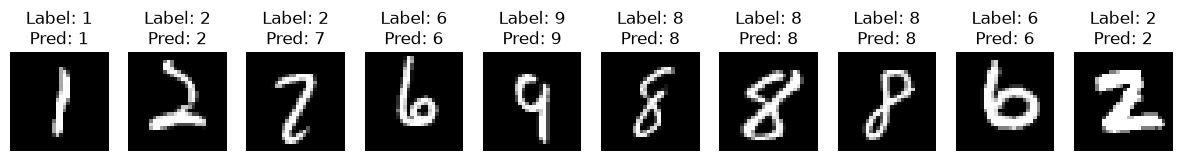

In [37]:
import matplotlib.pyplot as plt

num_images = 10

indices = np.random.choice(len(all_X), num_images, replace=False)

plt.figure(figsize=(15, 3))

for i, idx in enumerate(indices):

    image = all_X[idx].squeeze()
    label = all_y[idx]
    pred = all_preds[idx]

    plt.subplot(1, num_images, i + 1)
    plt.imshow(image, cmap='gray')

    plt.title(f'Label: {label}\nPred: {pred}')
    plt.axis('off')

plt.show()


### 오분류 이미지 확인

테스트 데이터에서 예측과 정답이 다른 이미지를 최대 10개까지 모아 시각화한다. 비슷한 숫자 모양이나 흐린 획처럼 모델이 혼동한 공통 특징이 있는지 살펴본다.

In [ ]:
import matplotlib.pyplot as plt

num_images = 10

indices = [i for i in range(len(all_X)) if all_preds[i] != all_y[i]]
indices = indices[:num_images]

plt.figure(figsize=(15, 3))

for i, idx in enumerate(indices):

    image = all_X[idx].squeeze()
    label = all_y[idx]
    pred = all_preds[idx]

    plt.subplot(1, num_images, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'Label: {label}\nPred: {pred}')
    plt.axis('off')

plt.show()
